<a href="https://colab.research.google.com/github/MhThorq/FraudDet/blob/main/Fraud_Detect.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [32]:
from google.colab import drive
import os
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [33]:
import pandas as pd
# Memanggil data yang sudah disimpan sebelumnya
train = pd.read_pickle('/content/drive/MyDrive/Fraud-Dataset/processed_data.pkl')

In [34]:
df = pd.read_pickle('/content/drive/MyDrive/Fraud-Dataset/processed_data.pkl')
df.head()

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M


In [35]:
# 1. Identifikasi kolom berdasarkan tipenya
cat_cols = df.select_dtypes(include=['object']).columns
num_cols = df.select_dtypes(exclude=['object']).columns

# 2. Imputasi kolom kategorikal dengan string khusus
df[cat_cols] = df[cat_cols].fillna('MISSING')

# 3. Imputasi kolom numerik dengan nilai di luar jangkauan data (misal -999)
df[num_cols] = df[num_cols].fillna(-999)

# 4. Lanjutkan dengan Label Encoding untuk kolom kategorikal
from sklearn.preprocessing import LabelEncoder
for col in cat_cols:
    le = LabelEncoder()
    # Tidak perlu astype(str) lagi karena sudah diisi dengan 'MISSING'
    df[col] = le.fit_transform(df[col])

print("Pre-processing selesai: Imputasi dipisahkan antara numerik (-999) dan kategorikal ('MISSING').")

Pre-processing selesai: Imputasi dipisahkan antara numerik (-999) dan kategorikal ('MISSING').


In [36]:
from sklearn.model_selection import train_test_split
import gc

# Misal kita ingin mengambil 20% data saja agar RAM aman
# df adalah dataframe gabungan (train) yang sudah Anda buat
X = df.drop('isFraud', axis=1)
y = df['isFraud']

# Melakukan stratified sampling
X_sample, _, y_sample, _ = train_test_split(
    X, y,
    train_size=0.2,      # Mengambil 20% data
    stratify=y,          # KUNCI: Menjaga rasio label Fraud
    random_state=42
)

# Menggabungkan kembali menjadi satu dataframe sampel
df_sample = pd.concat([X_sample, y_sample], axis=1)

# PENTING: Hapus dataframe lama dan bersihkan RAM
del df, X, y
gc.collect()

print(f"Sampling selesai. Ukuran data baru: {df_sample.shape}")

Sampling selesai. Ukuran data baru: (118108, 434)


In [37]:
# Memisahkan fitur (X) dan target (y) dari df_sample
X = df_sample.drop(['isFraud', 'TransactionID'], axis=1)
y = df_sample['isFraud']

# Tahap Unsupervised
from sklearn.ensemble import IsolationForest

# Menggunakan sebagian data (sampling) jika RAM terbatas, atau gunakan seluruhnya jika cukup
iso_forest = IsolationForest(n_estimators=100, contamination=0.03, random_state=42)
# Add anomaly score to df_sample
df_sample['anomaly_score'] = iso_forest.fit_predict(X)

# Update X with new anomaly_score feature
X['anomaly_score'] = df_sample['anomaly_score']
print("Skor anomali telah berhasil ditambahkan sebagai fitur baru.")

Skor anomali telah berhasil ditambahkan sebagai fitur baru.


In [38]:
# Masukkan ini sebelum proses training
# Membandingkan TransactionAmt dengan rata-rata per kartu (card1)
df_sample['Amt_to_mean_card1'] = df_sample['TransactionAmt'] / df_sample.groupby(['card1'])['TransactionAmt'].transform('mean')
df_sample['Amt_to_std_card1'] = df_sample['TransactionAmt'] / df_sample.groupby(['card1'])['TransactionAmt'].transform('std')

# Membandingkan TransactionAmt dengan rata-rata per alamat (addr1)
df_sample['Amt_to_mean_addr1'] = df_sample['TransactionAmt'] / df_sample.groupby(['addr1'])['TransactionAmt'].transform('mean')

# Mencegah NaN pada standar deviasi
df_sample['Amt_to_std_card1'] = df_sample['TransactionAmt'] / df_sample.groupby(['card1'])['TransactionAmt'].transform('std').fillna(1)

In [39]:
import numpy as np
# Mengonversi detik ke jam (0-23)
df_sample['Transaction_hour'] = np.floor(df_sample['TransactionDT'] / 3600) % 24
# Mengonversi detik ke hari dalam seminggu (0-6)
df_sample['Transaction_day'] = np.floor(df_sample['TransactionDT'] / (3600 * 24)) % 7

In [40]:
for col in ['card1', 'card2', 'card3', 'card5', 'addr1', 'P_emaildomain']:
    df_sample[col + '_count'] = df_sample[col].map(df_sample[col].value_counts(dropna=False))

In [41]:
# Contoh: Menghitung berapa kali kartu yang sama (card1) bertransaksi pada jam yang sama
df_sample['trans_count_per_hour'] = df_sample.groupby(['card1', 'Transaction_hour'])['TransactionAmt'].transform('count')

In [42]:
# Baris ini sudah benar untuk dataset IEEE-CIS (sel 25)
df_sample['Amt_to_mean_card1'] = df_sample['TransactionAmt'] / df_sample.groupby(['card1'])['TransactionAmt'].transform('mean')

In [43]:
import numpy as np

# 1. Definisikan ulang X agar fitur baru masuk
X = df_sample.drop(['isFraud', 'TransactionID'], axis=1)
y = df_sample['isFraud']

# 2. Ubah infinity (inf/-inf) menjadi NaN agar bisa diisi (imputasi)
X.replace([np.inf, -np.inf], np.nan, inplace=True)

# 3. Isi semua NaN (termasuk bekas infinity) dengan nilai -999
X.fillna(-999, inplace=True)

# 4. Lakukan split dan SMOTE seperti biasa
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

In [44]:
from sklearn.ensemble import RandomForestClassifier

# Inisialisasi dan training model
rf_model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
rf_model.fit(X_train_res, y_train_res)

print("Proses training Random Forest selesai!")

Proses training Random Forest selesai!



Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.98      0.98     22795
           1       0.47      0.43      0.45       827

    accuracy                           0.96     23622
   macro avg       0.73      0.71      0.72     23622
weighted avg       0.96      0.96      0.96     23622



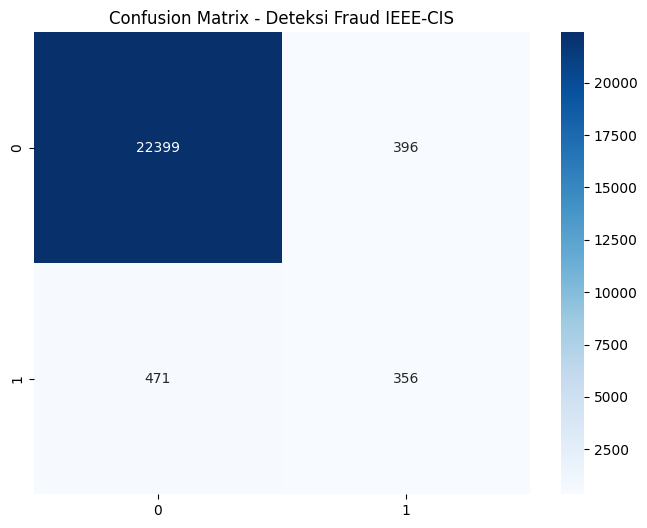

In [45]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = rf_model.predict(X_test)
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Visualisasi Confusion Matrix
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Deteksi Fraud IEEE-CIS')
plt.show()

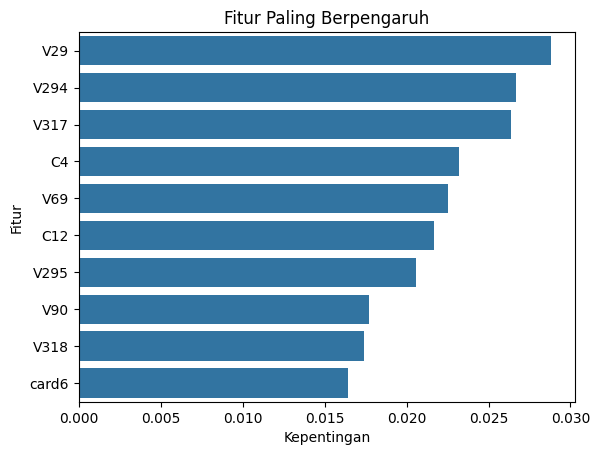

In [46]:
importances = rf_model.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Fitur': feature_names, 'Kepentingan': importances})
feature_importance_df = feature_importance_df.sort_values(by='Kepentingan', ascending=False)

# Visualisasi 10 fitur teratas
sns.barplot(x='Kepentingan', y='Fitur', data=feature_importance_df.head(10))
plt.title('Fitur Paling Berpengaruh')
plt.show()